# Dyna Playground

Interactive exploration of **Dyna-Q** and **Prioritized Sweeping** from the *RL in Practice* notes.

The environment is a configurable `GridWorld` with a goal, optional traps, and a step cost. The agent must learn to reach the goal while avoiding traps. See the environment setup cell below for the current layout.

**Key ideas:**
- **Dyna (random replay):** after every real step, replay `k` randomly chosen past transitions from a learned model. More replay → faster convergence, at the cost of extra computation per step.
- **Prioritized sweeping:** instead of random replay, direct simulated updates to states with the largest expected value change, propagating backward through predecessors.

## Environment setup

`GridWorld` encapsulates the full MDP (minus the policy). Create different environments by changing the constructor args:
- **State space:** `rows × cols` grid, indexed by `(row, col)`. Row 0 is the top.
- **Actions:** up, down, left, right — each is a `(Δrow, Δcol)` offset.
- **Transition function:** deterministic. Moves that would leave the grid are clipped (agent stays in place).
- **Reward function:** configurable rewards for goal, traps, and normal steps.

In [1]:
import numpy as np

class GridWorld:
    """Configurable grid world environment.
    
    Args:
        rows, cols: grid dimensions.
        goal: (row, col) of the goal cell.
        traps: set of (row, col) trap cells.
        start: (row, col) where each episode begins.
        goal_reward, trap_reward, step_cost: reward values.
    """
    # Each action is a (Δrow, Δcol) offset.  Row 0 is the top of the grid,
    # so "up" decreases the row index and "down" increases it.
    ACTIONS = [(-1,0),(1,0),(0,-1),(0,1)]
    ACTION_NAMES = ['up', 'down', 'left', 'right']
    N_ACTIONS = 4
    
    def __init__(self, rows=6, cols=6, goal=(0,5), traps=None,
                 start=(5,0), goal_reward=10.0, trap_reward=-10.0, step_cost=-0.1):
        self.rows = rows
        self.cols = cols
        self.goal = goal
        self.traps = set(traps) if traps else set()
        self.start = start
        self.goal_reward = goal_reward
        self.trap_reward = trap_reward
        self.step_cost = step_cost
    
    def cell_label(self, s):
        if s == self.goal:    return "GOAL"
        if s in self.traps:   return "TRAP"
        return "    "
    
    def step(self, s, a, verbose=False):
        """Take action a from state s. Returns (next_state, reward)."""
        nr, nc = s[0]+self.ACTIONS[a][0], s[1]+self.ACTIONS[a][1]
        nr = max(0, min(self.rows-1, nr))
        nc = max(0, min(self.cols-1, nc))
        s2 = (nr, nc)
        if s2 == self.goal:    r = self.goal_reward
        elif s2 in self.traps: r = self.trap_reward
        else:                  r = self.step_cost
        if verbose:
            tag = f" [{self.cell_label(s2)}]" if self.cell_label(s2).strip() else ""
            print(f"  {s} --{self.ACTION_NAMES[a]}--> {s2}{tag}  r={r:+.1f}")
        return s2, r
    
    def show_grid(self):
        """Print the grid layout: S=start, G=goal, X=trap, .=empty."""
        for r in range(self.rows):
            row = ""
            for c in range(self.cols):
                if (r,c) == self.start: row += "  S "
                elif (r,c) == self.goal:  row += "  G "
                elif (r,c) in self.traps: row += "  X "
                else:                     row += "  . "
            print(row)
        print()
    
    def __repr__(self):
        return (f"GridWorld({self.rows}x{self.cols}, start={self.start}, "
                f"goal={self.goal}, traps={self.traps})")

# Default environment
env = GridWorld(rows=8, cols=8, goal=(1,7), traps={(1,1),(1,2),(1,3),(1,4),(1,5),(1,6), (2,2),(3,2),(4,2),(5,2)}, start=(7,0))
print(env)
env.show_grid()

print("=== Sample transitions ===")
env.step((5, 0), 0, verbose=True)   # up from start
env.step((0, 4), 3, verbose=True)   # right into goal
env.step((2, 4), 0, verbose=True)   # up into trap
env.step((5, 1), 0, verbose=True)   # left from corner (clipped)

GridWorld(8x8, start=(7, 0), goal=(1, 7), traps={(1, 2), (1, 5), (1, 1), (4, 2), (1, 4), (2, 2), (1, 6), (3, 2), (1, 3), (5, 2)})
  .   .   .   .   .   .   .   . 
  .   X   X   X   X   X   X   G 
  .   .   X   .   .   .   .   . 
  .   .   X   .   .   .   .   . 
  .   .   X   .   .   .   .   . 
  .   .   X   .   .   .   .   . 
  .   .   .   .   .   .   .   . 
  S   .   .   .   .   .   .   . 

=== Sample transitions ===
  (5, 0) --up--> (4, 0)  r=-0.1
  (0, 4) --right--> (0, 5)  r=-0.1
  (2, 4) --up--> (1, 4) [TRAP]  r=-10.0
  (5, 1) --up--> (4, 1)  r=-0.1


((4, 1), -0.1)

## Step-by-step mode

`DynaAgent` lets you advance **one action at a time** or run full episodes in batch.
Supports two replay strategies via `prioritized=True/False`:
- **Random replay** (default): Dyna picks past transitions at random for simulated updates.
- **Prioritized sweeping**: updates are directed to states with the largest expected value change, propagating backward through predecessors.

Usage:
```python
agent = DynaAgent(env, k_sim=5)                    # random replay (Dyna)
agent = DynaAgent(env, k_sim=5, prioritized=True)  # prioritized sweeping
agent.single_step(verbose=True)                     # one action at a time
agent.show()                                        # policy + values
agent.run_episodes(80)                              # batch training
```

In [7]:
def show_policy_and_values(Q, env):
    """Display the greedy policy and V* for each cell.
    G = goal, X = trap, arrows = greedy action."""
    arrows = ['↑', '↓', '←', '→']
    pw = env.cols * 6       # column width scales with grid size
    vw = env.cols * 6
    print(f"{'Policy':^{pw}s}    {'V*(s) = max_a Q(s,a)':^{vw}s}")
    print(f"{'-'*pw:s}    {'-'*vw:s}")
    for r in range(env.rows):
        policy_row = ""
        value_row = ""
        for c in range(env.cols):
            if (r, c) == env.goal:
                policy_row += "  G   "
                value_row += "  G   "
            elif (r, c) in env.traps:
                policy_row += "  X   "
                value_row += f"{np.max(Q[r,c]):5.2f} "
            else:
                best_a = np.argmax(Q[r, c])
                policy_row += f"  {arrows[best_a]}   "
                value_row += f"{np.max(Q[r,c]):5.2f} "
        print(f"|{policy_row}|    |{value_row}|")
    print()
    
class DynaAgent:
    """Dyna-Q agent with optional prioritized sweeping.
    
    Args:
        env: GridWorld environment.
        k_sim: number of simulated updates per real step.
        prioritized: if True, use prioritized sweeping instead of random replay.
        priority_theta: minimum TD error to enter the priority queue.
        epsilon, gamma, alpha: standard RL hyperparameters.
        seed: random seed for reproducibility.
    """
    
    def __init__(self, env, k_sim=5, epsilon=0.1, gamma=0.95, alpha=0.1,
                 seed=0, prioritized=False, priority_theta=1e-4):
        np.random.seed(seed)
        self.env = env
        self.k_sim = k_sim
        self.epsilon = epsilon
        self.gamma = gamma
        self.alpha = alpha
        self.prioritized = prioritized
        self.priority_theta = priority_theta
        self.Q = np.zeros((env.rows, env.cols, env.N_ACTIONS))
        # The "model" is just a lookup table of observed transitions:
        # (s, a) -> (s', r).  Model-free Q-learning discards transitions
        # after one update; storing them here lets us replay them for free.
        self.model = {}
        self.visited = []
        self.predecessors = {}  # s' -> set of (s, a) that lead to s'
        # Priority queue: ranks (s, a) pairs by TD error magnitude —
        # "how wrong is our current estimate?"  Highest error = updated first.
        self.pq = {}
        self.s = env.start
        self.total_steps = 0
        self.episode = 0
        self.episode_steps = 0
    
    def _pq_push(self, s, a, priority):
        """Insert/update (s, a) in priority queue if above threshold."""
        if priority > self.priority_theta:
            key = (s, a)
            if key not in self.pq or priority > self.pq[key]:
                self.pq[key] = priority
    
    def _pq_pop(self):
        """Pop the (s, a) pair with highest priority. Returns None if empty."""
        if not self.pq:
            return None
        key = max(self.pq, key=self.pq.get)
        del self.pq[key]
        return key
    
    def _promote_predecessors(self, s):
        """After updating a state, check if its predecessors need requeueing."""
        if s not in self.predecessors:
            return
        for (sp, ap) in self.predecessors[s]:
            s2p, rp = self.model[(sp, ap)]
            p = abs(rp + self.gamma * np.max(self.Q[s2p]) - self.Q[sp][ap])
            self._pq_push(sp, ap, p)
    
    def single_step(self, verbose=True):
        """Take one real action, update Q, run k_sim simulated updates.
        Returns True if the episode ended (reached goal)."""
        s = self.s
        
        # ε-greedy action selection
        if np.random.random() > self.epsilon:
            a = np.argmax(self.Q[s])
            explore_tag = "greedy"
        else:
            a = np.random.randint(self.env.N_ACTIONS)
            explore_tag = "explore"
        
        s2, r = self.env.step(s, a, verbose=verbose)
        
        # Step 1: direct Q-learning update
        old_q = self.Q[s][a]
        td_target = r + self.gamma * np.max(self.Q[s2])
        self.Q[s][a] += self.alpha * (td_target - old_q)
        
        if verbose:
            print(f"    [{explore_tag}]  Q({s},{self.env.ACTION_NAMES[a]}): "
                  f"{old_q:.3f} → {self.Q[s][a]:.3f}  "
                  f"(target={td_target:.3f}, error={td_target - old_q:+.3f})")
        
        # Step 2: update model and track predecessors
        self.model[(s, a)] = (s2, r)
        if (s, a) not in self.visited:
            self.visited.append((s, a))
        if s2 not in self.predecessors:
            self.predecessors[s2] = set()
        self.predecessors[s2].add((s, a))
        
        # Step 3: simulated updates
        if self.prioritized:
            # Re-queue (s, a) even though step 1 already updated it.
            # alpha only nudges ~10% of the way, so ~90% of the error remains.
            # The priority (pre-update TD error) slightly overestimates staleness,
            # but the actual update recomputes the error fresh, so correctness
            # is unaffected — priority is just for ordering.
            self._pq_push(s, a, abs(td_target - old_q))
            # s's value just changed, so states that lead INTO s may now
            # have stale estimates — check them and queue if significant.
            self._promote_predecessors(s)
            
            n_sim = 0
            if self.k_sim > 0 and verbose:
                print(f"    Running up to {self.k_sim} prioritized updates...")
            for i in range(self.k_sim):
                # Always update the most "wrong" entry first.
                pair = self._pq_pop()
                if pair is None:
                    # Queue empty = all estimates are locally converged.
                    # Unlike random Dyna, we stop early instead of wasting
                    # computation on updates that won't change anything.
                    break
                si, ai = pair
                s2i, ri = self.model[(si, ai)]
                old_qi = self.Q[si][ai]
                self.Q[si][ai] += self.alpha * (
                    ri + self.gamma * np.max(self.Q[s2i]) - old_qi)
                n_sim += 1
                if verbose and self.k_sim <= 10:
                    print(f"      pri {i+1}: Q({si},{self.env.ACTION_NAMES[ai]}): "
                          f"{old_qi:.3f} → {self.Q[si][ai]:.3f}")
                # CASCADE: we just changed si's value, so si's predecessors
                # may now be stale too.  This is how a single value change
                # near the goal ripples backward through the whole grid —
                # each update potentially queues more predecessors.
                self._promote_predecessors(si)
            if verbose and n_sim < self.k_sim:
                print(f"    (queue emptied after {n_sim} updates)")
        else:
            if self.k_sim > 0 and verbose:
                print(f"    Running {self.k_sim} simulated updates...")
            for i in range(self.k_sim):
                si, ai = self.visited[np.random.randint(len(self.visited))]
                s2i, ri = self.model[(si, ai)]
                old_qi = self.Q[si][ai]
                self.Q[si][ai] += self.alpha * (
                    ri + self.gamma * np.max(self.Q[s2i]) - old_qi)
                if verbose and self.k_sim <= 10:
                    print(f"      sim {i+1}: Q({si},{self.env.ACTION_NAMES[ai]}): "
                          f"{old_qi:.3f} → {self.Q[si][ai]:.3f}")
        
        self.s = s2
        self.total_steps += 1
        self.episode_steps += 1
        
        done = (s2 == self.env.goal)
        if done:
            if verbose:
                print(f"  *** GOAL reached in {self.episode_steps} steps (episode {self.episode}) ***")
            self.episode += 1
            self.episode_steps = 0
            self.s = self.env.start
        
        return done
    
    def run_episode(self, verbose=False, max_steps=200):
        """Run a full episode. Returns number of steps taken."""
        for t in range(max_steps):
            if self.single_step(verbose=verbose):
                return t + 1
        return max_steps
    
    def run_episodes(self, n, verbose=False, max_steps=200):
        """Run n episodes. Returns list of step counts per episode."""
        return [self.run_episode(verbose=verbose, max_steps=max_steps) for _ in range(n)]
    
    def show(self):
        """Print current policy and value grid."""
        mode = "prioritized" if self.prioritized else "random"
        show_policy_and_values(self.Q, self.env)
        print(f"Total steps: {self.total_steps}  |  Episodes completed: {self.episode}  "
              f"|  Model entries: {len(self.model)}  |  Replay: {mode}")

print("DynaAgent ready.")

DynaAgent ready.


In [8]:
env = GridWorld(rows=8, cols=8, goal=(1,7), traps={(1,1),(1,2),(1,3),(1,4),(1,5),(1,6), (2,2),(3,2),(4,2),(5,2)}, start=(7,0))

# Create an agent and step through a few actions
agent = DynaAgent(env, k_sim=5, seed=42)

print("=== First 5 steps ===\n")
for i in range(5):
    print(f"--- Step {i+1} (state: {agent.s}) ---")
    agent.single_step(verbose=True)
    print()

print("=== Q-table and policy after 5 steps ===\n")
agent.show()


=== First 5 steps ===

--- Step 1 (state: (7, 0)) ---
  (7, 0) --up--> (6, 0)  r=-0.1
    [greedy]  Q((7, 0),up): 0.000 → -0.010  (target=-0.100, error=-0.100)
    Running 5 simulated updates...
      sim 1: Q((7, 0),up): -0.010 → -0.019
      sim 2: Q((7, 0),up): -0.019 → -0.027
      sim 3: Q((7, 0),up): -0.027 → -0.034
      sim 4: Q((7, 0),up): -0.034 → -0.041
      sim 5: Q((7, 0),up): -0.041 → -0.047

--- Step 2 (state: (6, 0)) ---
  (6, 0) --up--> (5, 0)  r=-0.1
    [greedy]  Q((6, 0),up): 0.000 → -0.010  (target=-0.100, error=-0.100)
    Running 5 simulated updates...
      sim 1: Q((7, 0),up): -0.047 → -0.052
      sim 2: Q((6, 0),up): -0.010 → -0.019
      sim 3: Q((7, 0),up): -0.052 → -0.057
      sim 4: Q((7, 0),up): -0.057 → -0.061
      sim 5: Q((7, 0),up): -0.061 → -0.065

--- Step 3 (state: (5, 0)) ---
  (5, 0) --up--> (4, 0)  r=-0.1
    [greedy]  Q((5, 0),up): 0.000 → -0.010  (target=-0.100, error=-0.100)
    Running 5 simulated updates...
      sim 1: Q((5, 0),up): -0

In [12]:
env = GridWorld(rows=8, cols=8, goal=(1,7), traps={(1,1),(1,2),(1,3),(1,4),(1,5),(1,6), (2,2),(3,2),(4,2),(5,2)}, start=(7,0))

agent = DynaAgent(env, k_sim=0, seed=42)
max_steps = 400
# Run one full episode with NO Dyna (pure Q-learning)
agent.run_episode(verbose=False, max_steps=max_steps)
print("After 1 episode (k=0):")
agent.show()

# Now reset and try with k=50
agent2 = DynaAgent(env, k_sim=20, seed=42)
agent2.run_episode(verbose=False, max_steps=max_steps)
print("After 1 episode (k=50):")
agent2.show()

# Now reset and try with k=50 and prioritized sweeping
agent2 = DynaAgent(env, k_sim=20, prioritized=True, seed=42)
agent2.run_episode(verbose=False, max_steps=max_steps)
print("After 1 episode (k=50):")
agent2.show()

After 1 episode (k=0):
                     Policy                                       V*(s) = max_a Q(s,a)              
------------------------------------------------    ------------------------------------------------
|  →     ←     ←     ←     ←     ↑     ←     ↑   |    |-0.02 -0.01 -0.01 -0.01 -0.01 -0.01  0.00  0.00 |
|  ↓     X     X     X     X     X     X     G   |    |-0.02 -0.01  0.00  0.00  0.00  0.00  1.00   G   |
|  ↓     ←     X     ←     ↑     ↑     ↑     ↑   |    |-0.02 -0.02  0.00  0.00  0.00  0.00  0.00  0.00 |
|  ↓     ↑     X     ←     ↑     ↑     ↑     ↑   |    |-0.02 -0.03  0.00  0.00  0.00  0.00  0.00  0.00 |
|  →     ↓     X     →     ↑     ↑     ↑     ↑   |    |-0.01 -0.02 -0.01  0.00  0.00  0.00  0.00  0.00 |
|  ←     ↓     X     ←     ↑     ↑     ↑     ↑   |    |-0.01 -0.01  0.00  0.00  0.00  0.00  0.00  0.00 |
|  ←     ↓     ←     →     ↑     ↑     ↑     ↑   |    |-0.01 -0.01 -0.01  0.00  0.00  0.00  0.00  0.00 |
|  ↑     →     →     ↓     ↑     ↑     ↑

## Batch experiments

Compare different values of `k` by creating agents, training them, and inspecting the results.

In [17]:
agents = {}
configs = [
    ("Q-learn (k=0)",    dict(k_sim=0,  prioritized=False)),
    ("Dyna k=5",         dict(k_sim=5,  prioritized=False)),
    ("Dyna k=20",        dict(k_sim=20, prioritized=False)),
    ("PriSweep k=5",     dict(k_sim=5,  prioritized=True)),
    ("PriSweep k=20",    dict(k_sim=20, prioritized=True)),
]

for name, kwargs in configs:
    a = DynaAgent(env, seed=0, **kwargs)
    steps = a.run_episodes(80)
    agents[name] = (a, steps)
    print(f"{name:20s}: V(start)={np.max(a.Q[env.start]):6.2f}  "
          f"Avg steps (last 20)={np.mean(steps[-20:]):.1f}")

print()
for name in ["Q-learn (k=0)", "Dyna k=20", "PriSweep k=20"]:
    a, _ = agents[name]
    print(f"=== {name} ===")
    a.show()
    print()

Q-learn (k=0)       : V(start)= -0.41  Avg steps (last 20)=26.2
Dyna k=5            : V(start)=  0.72  Avg steps (last 20)=15.2
Dyna k=20           : V(start)=  4.30  Avg steps (last 20)=14.2
PriSweep k=5        : V(start)=  0.39  Avg steps (last 20)=14.2
PriSweep k=20       : V(start)=  3.53  Avg steps (last 20)=14.4

=== Q-learn (k=0) ===
                     Policy                                       V*(s) = max_a Q(s,a)              
------------------------------------------------    ------------------------------------------------
|  ↑     ↑     ↑     →     →     →     →     ↓   |    |-0.23 -0.20 -0.16 -0.11  0.09  0.88  2.87  6.86 |
|  ↑     X     X     X     X     X     X     G   |    |-0.26 -0.04 -0.05 -0.02 -0.01  0.04  3.44   G   |
|  ↑     ←     X     →     →     →     →     ↑   |    |-0.28 -0.29 -0.01 -0.03  0.98  7.93  9.16  9.99 |
|  ↑     ↑     X     →     →     ↑     ↑     ↑   |    |-0.30 -0.30 -0.07 -0.04  0.77  6.21  1.75  7.29 |
|  ←     ←     X     →     →     ↑ 

## Learning curves: steps per episode over training

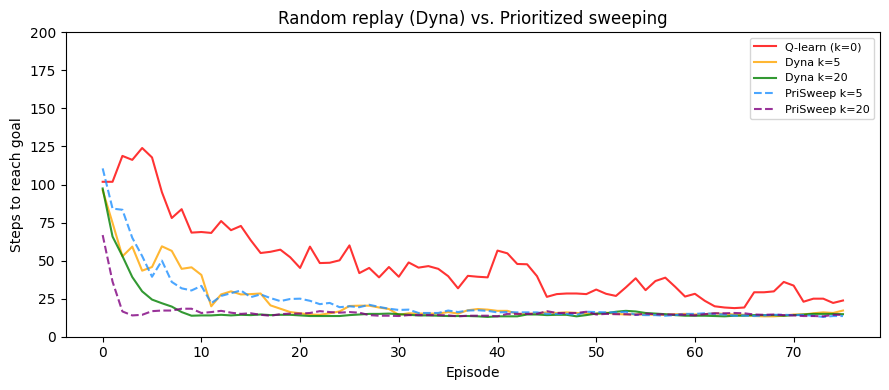

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
plot_configs = [
    ("Q-learn (k=0)",  "red",       "-"),
    ("Dyna k=5",       "orange",    "-"),
    ("Dyna k=20",      "green",     "-"),
    ("PriSweep k=5",   "dodgerblue","--"),
    ("PriSweep k=20",  "purple",    "--"),
]
for name, color, ls in plot_configs:
    _, steps = agents[name]
    smoothed = np.convolve(steps, np.ones(5)/5, mode='valid')
    ax.plot(smoothed, label=name, color=color, linestyle=ls, alpha=0.8)

ax.set_xlabel('Episode')
ax.set_ylabel('Steps to reach goal')
ax.set_title('Random replay (Dyna) vs. Prioritized sweeping')
ax.legend(fontsize=8)
ax.set_ylim(0, 200)
plt.tight_layout()
plt.show()